In [90]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/advaitmankar/housing/Housing.csv


In [155]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [159]:
df = pd.read_csv('/kaggle/input/datasets/advaitmankar/housing/Housing.csv')

In [160]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [161]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [162]:
print(df.shape)

(545, 13)


In [163]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [165]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [166]:
df.duplicated().sum()

np.int64(0)

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530 entries, 15 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             530 non-null    int64 
 1   area              530 non-null    int64 
 2   bedrooms          530 non-null    int64 
 3   bathrooms         530 non-null    int64 
 4   stories           530 non-null    int64 
 5   mainroad          530 non-null    object
 6   guestroom         530 non-null    object
 7   basement          530 non-null    object
 8   hotwaterheating   530 non-null    object
 9   airconditioning   530 non-null    object
 10  parking           530 non-null    int64 
 11  prefarea          530 non-null    object
 12  furnishingstatus  530 non-null    object
dtypes: int64(6), object(7)
memory usage: 58.0+ KB


In [168]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [169]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530 entries, 15 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            530 non-null    int64
 1   area                             530 non-null    int64
 2   bedrooms                         530 non-null    int64
 3   bathrooms                        530 non-null    int64
 4   stories                          530 non-null    int64
 5   parking                          530 non-null    int64
 6   mainroad_yes                     530 non-null    bool 
 7   guestroom_yes                    530 non-null    bool 
 8   basement_yes                     530 non-null    bool 
 9   hotwaterheating_yes              530 non-null    bool 
 10  airconditioning_yes              530 non-null    bool 
 11  prefarea_yes                     530 non-null    bool 
 12  furnishingstatus_semi-furnished  530 non-null    bool 

In [170]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
]

In [158]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

df['area_per_bedroom'] = (
    df['area'] / df['bedrooms']
)

In [180]:
print(df['bedrooms'].min())

1


In [181]:
df['area_per_bedroom'] = (
    df['area'] / df['bedrooms'].replace(0, 1)
)

In [182]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [183]:
X = df_encoded.drop('price', axis=1)

y = df_encoded['price']

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [185]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R²:", lr_r2)

Linear Regression R²: 0.7136467114596604


In [186]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R²:", rf_r2)

Random Forest R²: 0.6826338950995718


In [177]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,734390.831090,9.796748e+05,0.713647
1,Random Forest,762252.557173,1.031362e+06,0.682634


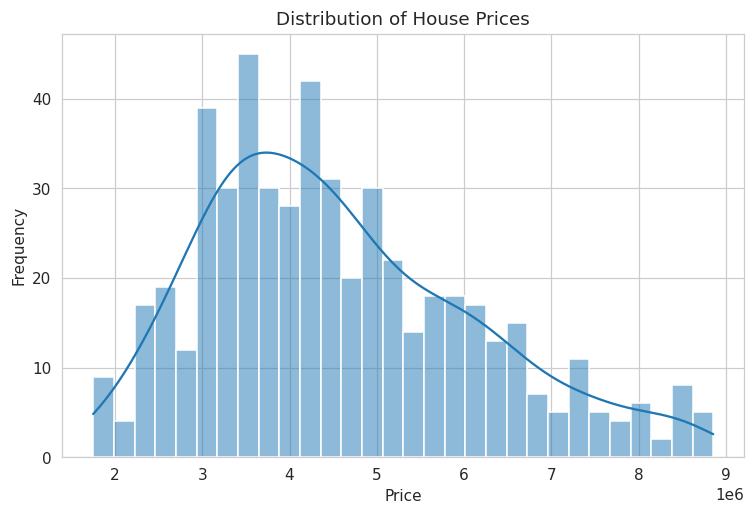

In [187]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.savefig('chart1_price_distribution.png')

plt.show()

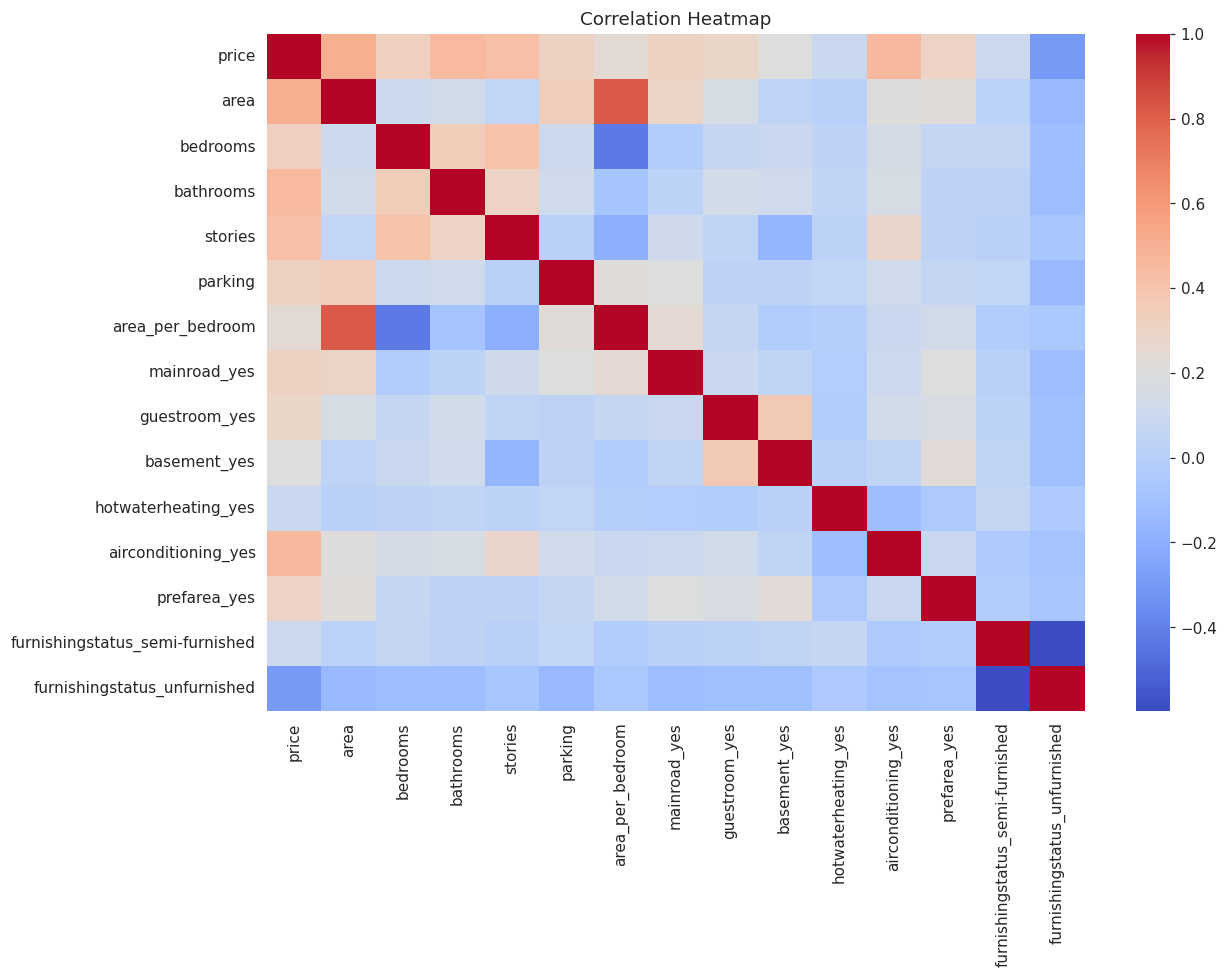

In [188]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('chart2_correlation_heatmap.png')

plt.show()

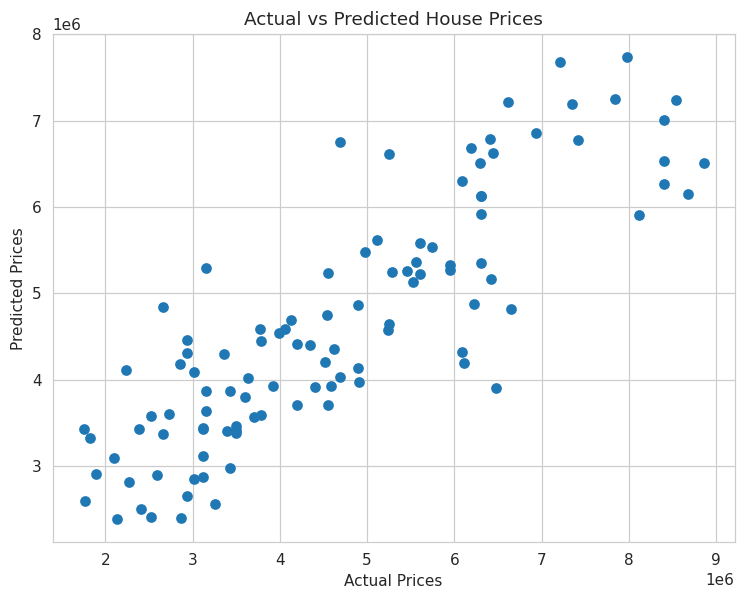

In [189]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.title('Actual vs Predicted House Prices')

plt.savefig('chart3_actual_vs_predicted.png')

plt.show()

In [190]:
correlation_with_price = (
    df_encoded.corr()['price']
    .sort_values(ascending=False)
)

print(correlation_with_price)

price                              1.000000
area                               0.512801
airconditioning_yes                0.458907
bathrooms                          0.452676
stories                            0.430699
bedrooms                           0.326890
parking                            0.312787
mainroad_yes                       0.311438
prefarea_yes                       0.301001
guestroom_yes                      0.283291
area_per_bedroom                   0.243458
basement_yes                       0.195148
furnishingstatus_semi-furnished    0.095927
hotwaterheating_yes                0.089984
furnishingstatus_unfurnished      -0.295681
Name: price, dtype: float64


House Price Prediction – Summary

The objective of this project was to develop a machine learning model capable of predicting house prices based on property characteristics. The dataset was explored, cleaned, and preprocessed by handling categorical variables through one-hot encoding and removing outliers to improve model performance. Additional features such as total rooms and area per bedroom were created to enhance predictive capability.

Two regression models were trained and evaluated: Linear Regression and Random Forest Regressor. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The Linear Regression model achieved the best results with an R² score of approximately 0.71, indicating that the model successfully explained about 71% of the variation in house prices.

The analysis revealed that area, number of bathrooms, air conditioning availability, number of stories, parking spaces, and preferred location were the most influential factors affecting house prices. Larger houses with more amenities consistently showed higher market values.

One notable observation was that amenities such as air conditioning and preferred area status significantly influenced pricing despite being simple categorical variables. Based on these findings, real estate businesses should focus on property size, amenities, and location when estimating prices and marketing properties. The developed model can serve as a useful decision-support tool for both buyers and sellers in the housing market.